In [2]:
import pandas as pd
# load new dataset from text classification
books = pd.read_csv("books_with_categories.csv")

In [3]:
# classify text into seven categories: anger, disgust, fear, joy , neutral, sadness, surprise 
# to classify the dominant emotion expressed in our book descriptions
# We could do this classification using zero shot classification as long as the dataset that the model was originally trained on contains sufficient association between emotional tone and book descriptions. 
#  But better we will use fine tuning in order to get an llm that can do emotional classifications. 
books

,isbn13,isbn10,title,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,tagged_description,simple_categories
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,9780002005883 A NOVEL THAT READERS and critics...,Fiction
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,9780002261982 A new 'Christie for Christmas' -...,Fiction
2,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,"9780006178736 A memorable, mesmerizing heroine...",Fiction
3,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,9780006280897 Lewis' work on the nature of lov...,Nonfiction
4,9780006280934,0006280935,The Problem of Pain,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,176.0,37569.0,"9780006280934 ""In The Problem of Pain, C.S. Le...",Nonfiction
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5192,9788172235222,8172235224,Mistaken Identity,Nayantara Sahgal,Indic fiction (English),http://books.google.com/books/content?id=q-tKP...,On A Train Journey Home To North India After L...,2003.0,2.93,324.0,0.0,9788172235222 On A Train Journey Home To North...,Fiction
5193,9788173031014,8173031010,Journey to the East,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0,9788173031014 This book tells the tale of a ma...,Nonfiction
5194,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0,9788179921623 Wisdom to Create a Life of Passi...,Fiction
5195,9788185300535,8185300534,I Am that,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,9788185300535 This collection of the timeless ...,Nonfiction


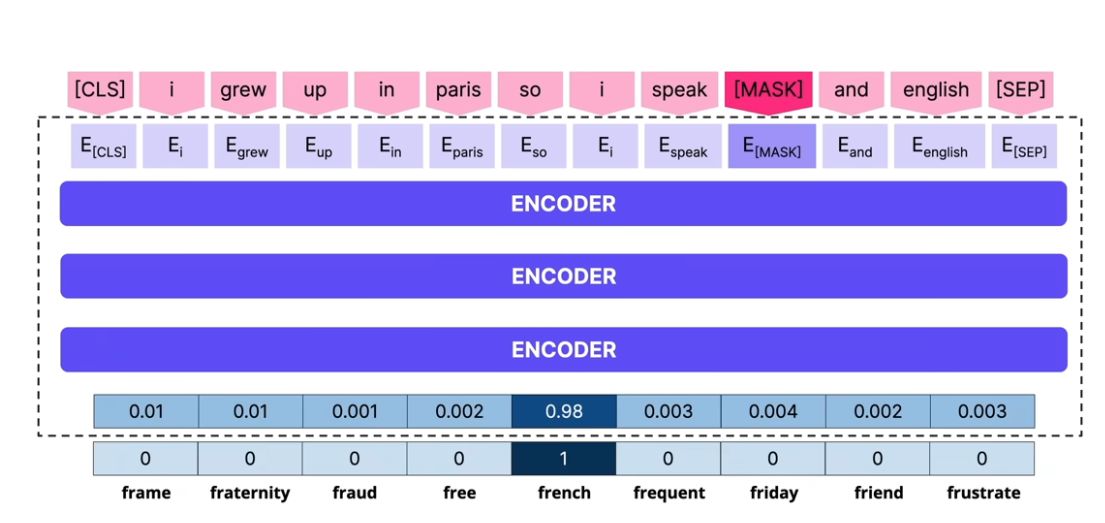

Example: Roberta model is made up by a sequence of layers e.g word embedding, encoder and final layer which allow th emodel to do those mask word prediction task that it was initially trained to do. 
With fine tuning we can throw away those final layers that we used to do that mass word prediction task and we can replace them with layers that instead are used to predict emotion categories. 
Then we take a small labelled dataset where this dataset contains text and the associated emotion and we can further train the model using this. 
Doing this we have not touched the encoding layers (e.g reset, delete them) meaning that the model has preserved all that rich info about language that it learned from its original training. So we can use that info plus the info from the emotion dataset so that we get an llm that is trained to classify the emotion of a text. 

We will not do the fine tuning here. We will use a model from hugging face hub that someone else has finetuned and uploaded. 

In [4]:
# Treat sentiment analysis as a text classification problem 
from transformers import pipeline 
classifier = pipeline("text-classification", model ='j-hartmann/emotion-english-distilroberta-base',top_k=None)
classifier("I love this!")


c:\Users\Aikaterini\anaconda3\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


[[{'label': 'joy', 'score': 0.9771687984466553},
  {'label': 'surprise', 'score': 0.008528684265911579},
  {'label': 'neutral', 'score': 0.005764586851000786},
  {'label': 'anger', 'score': 0.004419783595949411},
  {'label': 'sadness', 'score': 0.002092392183840275},
  {'label': 'disgust', 'score': 0.0016119909705594182},
  {'label': 'fear', 'score': 0.0004138524236623198}]]

We check evaluation metrics for this model . How well did this model perform at doing this classification?
https://dataloop.ai/library/model/j-hartmann_emotion-english-distilroberta-base/
So 66% accuracy which is quite higher than the random chance baseline of 14% (100/7 = 14 per category)


Do we get the sentiment classifier to try to 
1. predict the emotion of the overall description or 
2. Break it down to individual sentences and try to predict the sentiment of each of those. 
Better solution is 2. because in one description different sentences might have different sentiments. One description could have a mixture of different sentiments e.g joyus and fear

In [5]:
# Method 1 : Classify on the whole description
classifier(books["description"][0])

[[{'label': 'fear', 'score': 0.6548399925231934},
  {'label': 'neutral', 'score': 0.16985240578651428},
  {'label': 'sadness', 'score': 0.11640968173742294},
  {'label': 'surprise', 'score': 0.02070068009197712},
  {'label': 'disgust', 'score': 0.019100721925497055},
  {'label': 'joy', 'score': 0.015161454677581787},
  {'label': 'anger', 'score': 0.003935149870812893}]]

In [6]:
# Method 2: Classify each sentence in the description
# Split on the basis of fullstops
classifier(books["description"][0].split("."))

[[{'label': 'surprise', 'score': 0.7296021580696106},
  {'label': 'neutral', 'score': 0.1403859257698059},
  {'label': 'fear', 'score': 0.06816229224205017},
  {'label': 'joy', 'score': 0.0479426234960556},
  {'label': 'anger', 'score': 0.009156367741525173},
  {'label': 'disgust', 'score': 0.0026284754276275635},
  {'label': 'sadness', 'score': 0.002122163772583008}],
 [{'label': 'neutral', 'score': 0.44937002658843994},
  {'label': 'disgust', 'score': 0.2735920250415802},
  {'label': 'joy', 'score': 0.10908310860395432},
  {'label': 'sadness', 'score': 0.09362731128931046},
  {'label': 'anger', 'score': 0.04047829657793045},
  {'label': 'surprise', 'score': 0.02697014808654785},
  {'label': 'fear', 'score': 0.006879037246108055}],
 [{'label': 'neutral', 'score': 0.6462154984474182},
  {'label': 'sadness', 'score': 0.24273371696472168},
  {'label': 'disgust', 'score': 0.04342273622751236},
  {'label': 'surprise', 'score': 0.02830054983496666},
  {'label': 'joy', 'score': 0.01421148236

In [7]:
# Compare the prediction to the sentence just for a first test
sentences = books["description"][0].split(".")
predictions = classifier(sentences)
print(sentences[0])
print(predictions[0])



A NOVEL THAT READERS and critics have been eagerly anticipating for over a decade, Gilead is an astonishingly imagined story of remarkable lives
[{'label': 'surprise', 'score': 0.7296021580696106}, {'label': 'neutral', 'score': 0.1403859257698059}, {'label': 'fear', 'score': 0.06816229224205017}, {'label': 'joy', 'score': 0.0479426234960556}, {'label': 'anger', 'score': 0.009156367741525173}, {'label': 'disgust', 'score': 0.0026284754276275635}, {'label': 'sadness', 'score': 0.002122163772583008}]


In [8]:
print(sentences[3])
print(predictions[3])

 Haunted by his grandfather’s presence, John tells of the rift between his grandfather and his father: the elder, an angry visionary who fought for the abolitionist cause, and his son, an ardent pacifist
[{'label': 'fear', 'score': 0.9281681180000305}, {'label': 'anger', 'score': 0.03219098597764969}, {'label': 'neutral', 'score': 0.01280870009213686}, {'label': 'sadness', 'score': 0.008756876923143864}, {'label': 'surprise', 'score': 0.008597927168011665}, {'label': 'disgust', 'score': 0.008431834168732166}, {'label': 'joy', 'score': 0.001045584212988615}]


# Since now we have introduced multiple emotions for one description. 
# We need to process this output of each sentence and curate it so it gives us only one maximum score 
''For each book we can have a seperate column for each of the seven emotions. Instead of assigning a category of what it is and what it isnt. Take the highest probability 
from across the whole description, for that particular sentiment. So for example if joy is very high in one sentence but low across the other sentences 
we will just take the higher score of joy for that book description. 

In [9]:
sorted(predictions[0], key=lambda x: x["label"])


[{'label': 'anger', 'score': 0.009156367741525173},
 {'label': 'disgust', 'score': 0.0026284754276275635},
 {'label': 'fear', 'score': 0.06816229224205017},
 {'label': 'joy', 'score': 0.0479426234960556},
 {'label': 'neutral', 'score': 0.1403859257698059},
 {'label': 'sadness', 'score': 0.002122163772583008},
 {'label': 'surprise', 'score': 0.7296021580696106}]

In [10]:
import numpy as np

emotion_labels = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]
isbn = []
emotion_scores = {label: [] for label in emotion_labels}

def calculate_max_emotion_scores(predictions):
    per_emotion_scores = {label: [] for label in emotion_labels}
    for prediction in predictions:
        sorted_predictions = sorted(prediction, key=lambda x: x["label"])
        for index, label in enumerate(emotion_labels):
            per_emotion_scores[label].append(sorted_predictions[index]["score"])
    return {label: np.max(scores) for label, scores in per_emotion_scores.items()}


In [11]:
for i in range(10):
    isbn.append(books["isbn13"][i])
    sentences = books["description"][i].split(".")
    predictions = classifier(sentences)
    max_scores = calculate_max_emotion_scores(predictions)
    for label in emotion_labels:
        emotion_scores[label].append(max_scores[label])


In [12]:
from tqdm import tqdm

emotion_labels = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]
isbn = []
emotion_scores = {label: [] for label in emotion_labels}

for i in tqdm(range(len(books))):
    isbn.append(books["isbn13"][i])
    sentences = books["description"][i].split(".")
    predictions = classifier(sentences)
    max_scores = calculate_max_emotion_scores(predictions)
    for label in emotion_labels:
        emotion_scores[label].append(max_scores[label])


100%|██████████| 5197/5197 [21:54<00:00,  3.95it/s]


In [13]:
emotions_df = pd.DataFrame(emotion_scores)
emotions_df["isbn13"] = isbn


In [14]:
books = pd.merge(books, emotions_df, on = "isbn13")


In [15]:
books.to_csv("books_with_emotions.csv", index = False)